<a href="https://colab.research.google.com/github/tiagoflorin/DataScience2/blob/Clase_3/Clase_3_26_1_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Unidad 3. Machine Learning para la Ciencia de Datos
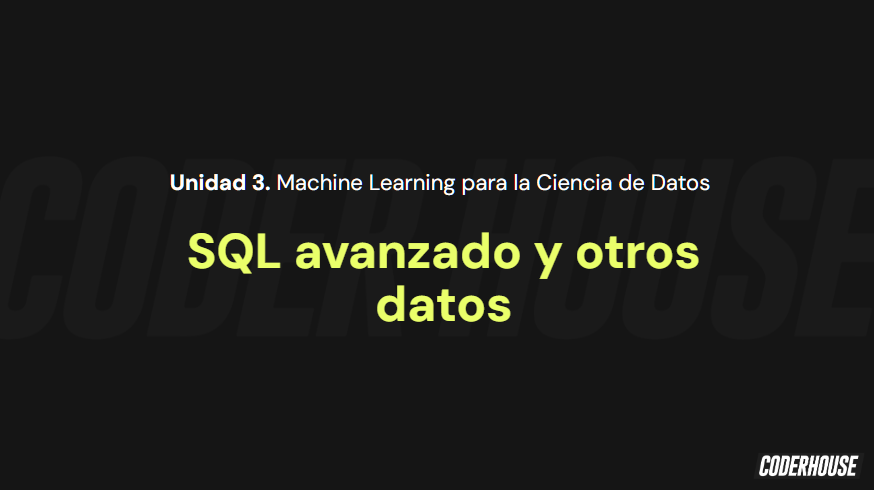



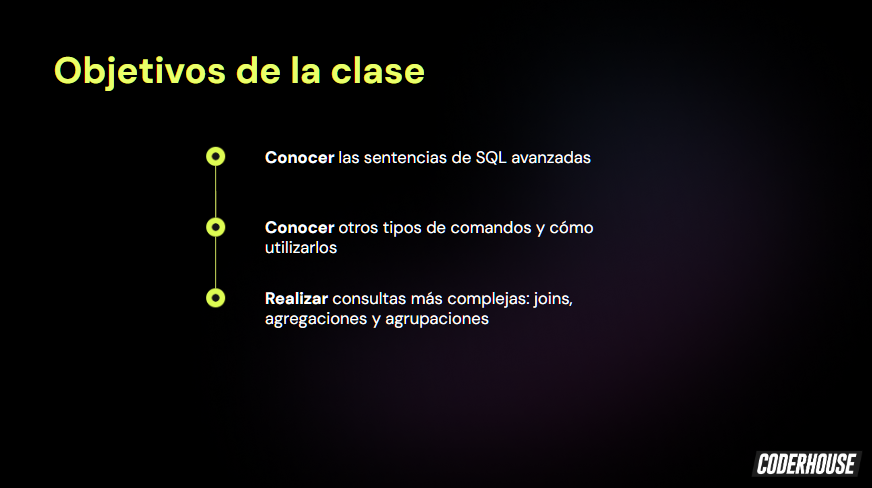

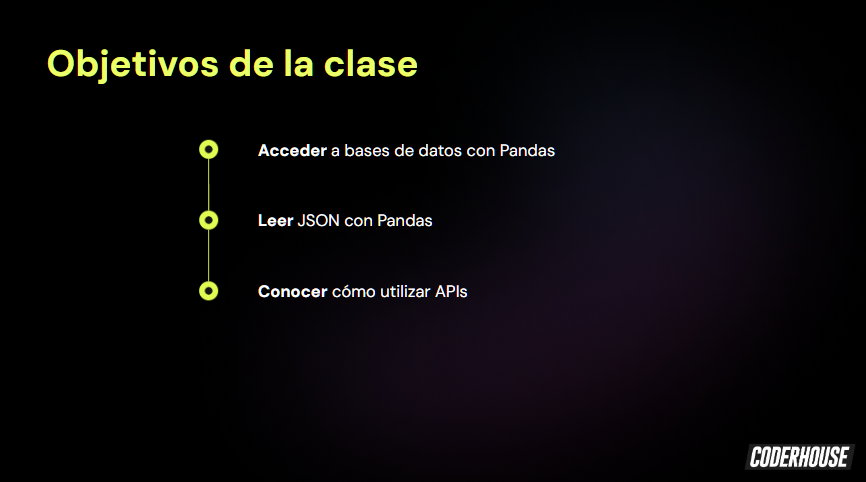

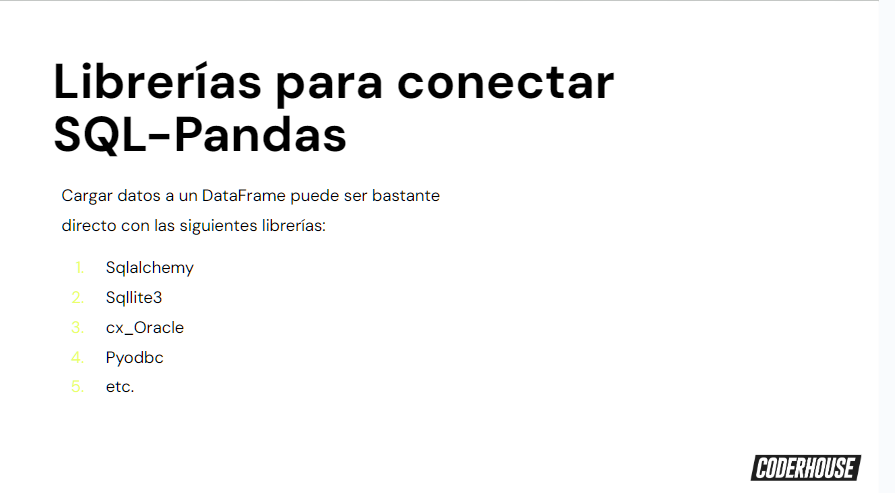

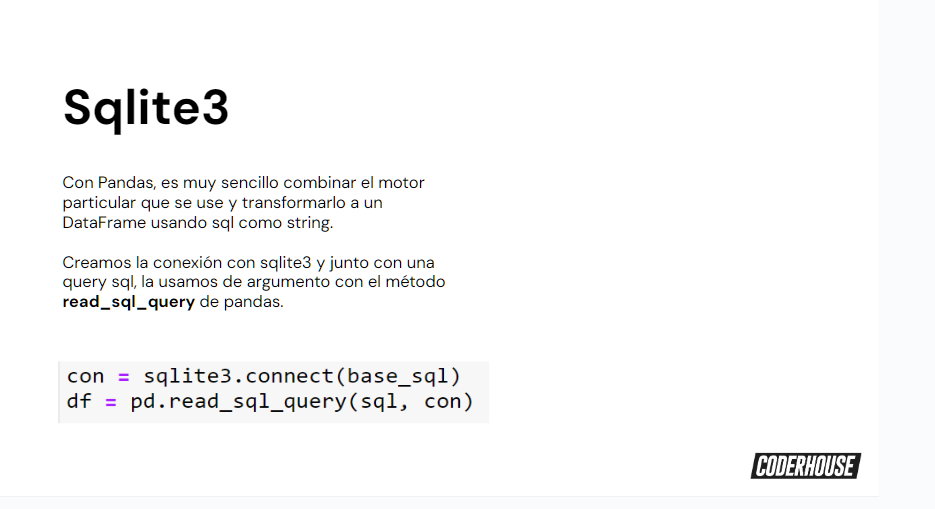

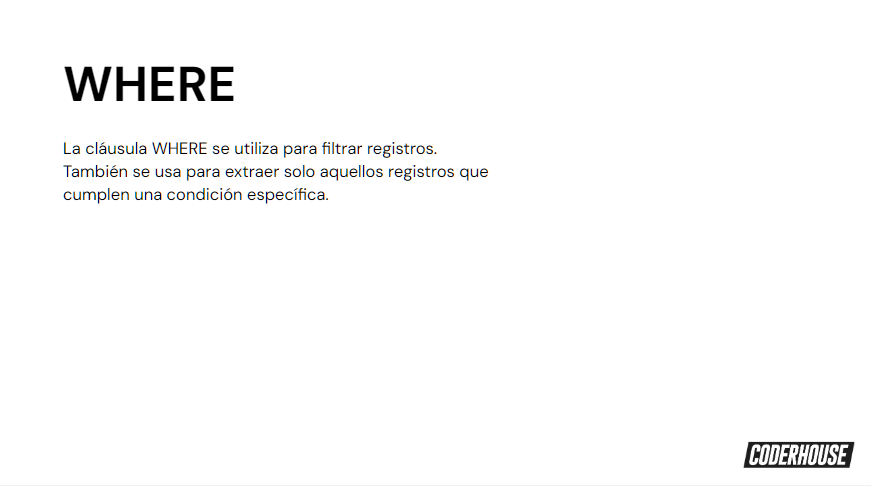

In [ ]:
!pip install -q gdown

import sqlite3
import subprocess
import pandas as pd
from pathlib import Path

# ID del archivo en Google Drive
file_id = "1JPRUk-ymAS6Lvd0kPrfRwVFJ9daUa9vM"
outfile = "nba.sqlite"

# Descargar archivo desde Drive
subprocess.run(["gdown", "--id", file_id, "-O", outfile], check=True)

# Verificar descarga
if not Path(outfile).exists():
    raise FileNotFoundError(f"No se descargó {outfile}")

# Conexión a SQLite
conn = sqlite3.connect(outfile)

# Listar tablas disponibles
tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%';",
    conn
)

print("Tablas disponibles:", tables["name"].tolist())

# Cargar tabla principal
df = pd.read_sql(
    "SELECT * FROM NBA_season1718_salary;",
    conn
)

# Cerrar conexión
conn.close()

# Resultado
print("Shape:", df.shape)
display(df.head())

Tablas disponibles: ['NBA_season1718_salary', 'Seasons_Stats']
Shape: (573, 4)


,X1,Player,Tm,season17_18
0,1.0,Stephen Curry,GSW,34682550.0
1,2.0,LeBron James,CLE,33285709.0
2,3.0,Paul Millsap,DEN,31269231.0
3,4.0,Gordon Hayward,BOS,29727900.0
4,5.0,Blake Griffin,DET,29512900.0


In [ ]:
# === CELDA 1: WHERE en NBA_season1718_salary ===

import sqlite3
import pandas as pd

conn = sqlite3.connect("nba.sqlite")

query = """
SELECT Player, Tm, season17_18 AS salario
FROM NBA_season1718_salary
WHERE season17_18 > 20000000
ORDER BY season17_18 DESC;
"""

df_salarios = pd.read_sql(query, conn)
conn.close()

print("Jugadores con salario mayor a 20 millones:")
display(df_salarios)

Jugadores con salario mayor a 20 millones:


,Player,Tm,salario
0,Stephen Curry,GSW,34682550.0
1,LeBron James,CLE,33285709.0
2,Paul Millsap,DEN,31269231.0
3,Gordon Hayward,BOS,29727900.0
4,Blake Griffin,DET,29512900.0
5,Kyle Lowry,TOR,28703704.0
6,Russell Westbrook,OKC,28530608.0
7,Mike Conley,MEM,28530608.0
8,James Harden,HOU,28299399.0
9,DeMar DeRozan,TOR,27739975.0


In [ ]:
# === CELDA 2: WHERE en Seasons_Stats ===

import sqlite3
import pandas as pd

conn = sqlite3.connect("nba.sqlite")

query = """
SELECT Player, Tm, PTS
FROM Seasons_Stats
WHERE PTS > 2000
ORDER BY PTS DESC;
"""

df_stats = pd.read_sql(query, conn)
conn.close()

print("Jugadores con más de 2000 puntos en una temporada:")
display(df_stats)

Jugadores con más de 2000 puntos en una temporada:


,Player,Tm,PTS
0,Wilt Chamberlain*,PHW,4029.0
1,Wilt Chamberlain*,SFW,3586.0
2,Michael Jordan*,CHI,3041.0
3,Wilt Chamberlain*,PHW,3033.0
4,Wilt Chamberlain*,SFW,2948.0
...,...,...,...
248,Kevin McHale*,BOS,2008.0
249,Hakeem Olajuwon*,HOU,2005.0
250,Tracy McGrady,HOU,2003.0
251,Elgin Baylor*,LAL,2002.0


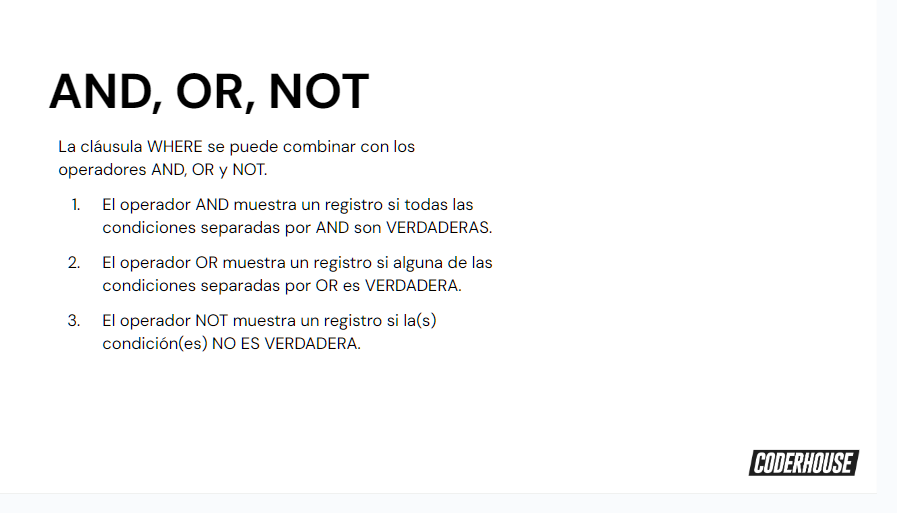

In [ ]:
# === CELDA 1: WHERE + AND ===

import sqlite3
import pandas as pd

conn = sqlite3.connect("nba.sqlite")


query = """
SELECT Player, Tm, PTS
FROM Seasons_Stats
WHERE PTS > 2000
AND Tm = 'CHI'
ORDER BY PTS DESC;
"""


df_and = pd.read_sql(query, conn)
conn.close()


print("Jugadores con más de 2000 puntos Y que jugaron en CHI:")
display(df_and)

Jugadores con más de 2000 puntos Y que jugaron en CHI:


,Player,Tm,PTS
0,Michael Jordan*,CHI,3041.0
1,Michael Jordan*,CHI,2868.0
2,Michael Jordan*,CHI,2753.0
3,Michael Jordan*,CHI,2633.0
4,Michael Jordan*,CHI,2580.0
5,Michael Jordan*,CHI,2541.0
6,Michael Jordan*,CHI,2491.0
7,Michael Jordan*,CHI,2431.0
8,Michael Jordan*,CHI,2404.0
9,Michael Jordan*,CHI,2357.0


In [ ]:
# === CELDA 3: WHERE + NOT ===

import sqlite3
import pandas as pd

conn = sqlite3.connect("nba.sqlite")

query = """
SELECT Player, Tm, PTS
FROM Seasons_Stats
WHERE NOT Tm = 'GSW'
ORDER BY PTS DESC
LIMIT 20;
"""

df_not = pd.read_sql(query, conn)
conn.close()

print("Jugadores que NO jugaron en GSW:")
display(df_not)

Jugadores que NO jugaron en GSW:


,Player,Tm,PTS
0,Wilt Chamberlain*,PHW,4029.0
1,Wilt Chamberlain*,SFW,3586.0
2,Michael Jordan*,CHI,3041.0
3,Wilt Chamberlain*,PHW,3033.0
4,Wilt Chamberlain*,SFW,2948.0
5,Michael Jordan*,CHI,2868.0
6,Kobe Bryant,LAL,2832.0
7,Bob McAdoo*,BUF,2831.0
8,Kareem Abdul-Jabbar*,MIL,2822.0
9,Rick Barry*,SFW,2775.0


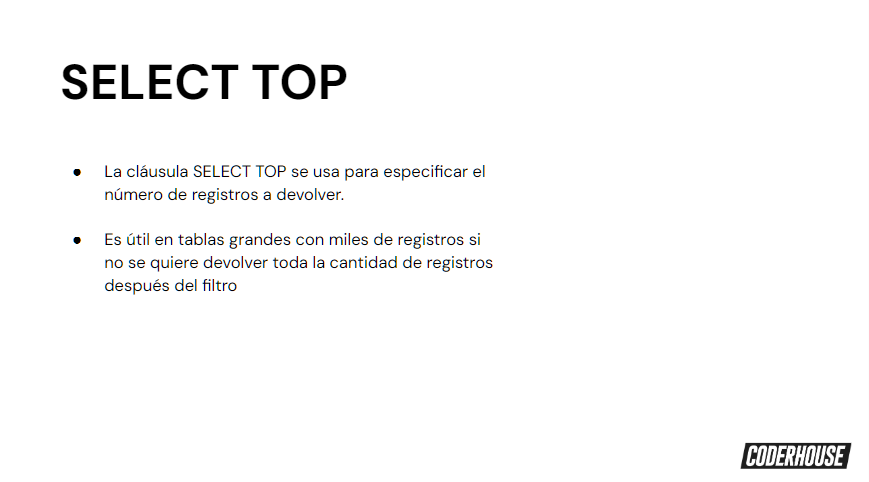

In [ ]:
# === CELDA 1: equivalente a SELECT TOP ===

import sqlite3
import pandas as pd

conn = sqlite3.connect("nba.sqlite")

query = """
SELECT Player, Tm, season17_18
FROM NBA_season1718_salary
LIMIT 10;
"""

df_top = pd.read_sql(query, conn)
conn.close()


print("Primeros 10 registros:")
display(df_top)

Primeros 10 registros:


,Player,Tm,season17_18
0,Stephen Curry,GSW,34682550.0
1,LeBron James,CLE,33285709.0
2,Paul Millsap,DEN,31269231.0
3,Gordon Hayward,BOS,29727900.0
4,Blake Griffin,DET,29512900.0
5,Kyle Lowry,TOR,28703704.0
6,Russell Westbrook,OKC,28530608.0
7,Mike Conley,MEM,28530608.0
8,James Harden,HOU,28299399.0
9,DeMar DeRozan,TOR,27739975.0


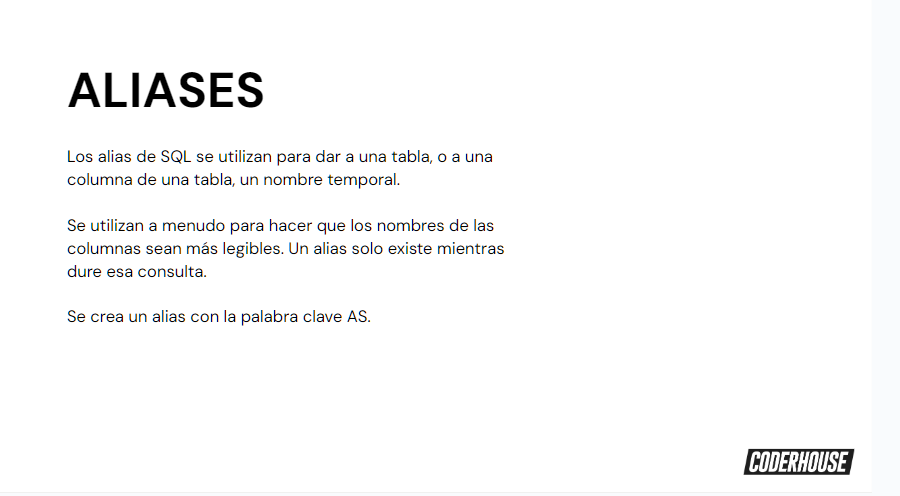

In [ ]:
# === ALIAS DE COLUMNAS ===

import sqlite3
import pandas as pd

conn = sqlite3.connect("nba.sqlite")

query = """
SELECT
Player AS jugador,
Tm AS equipo,
season17_18 AS salario
FROM NBA_season1718_salary
LIMIT 10;
"""

df_alias_columnas = pd.read_sql(query, conn)
conn.close()

display(df_alias_columnas)

,jugador,equipo,salario
0,Stephen Curry,GSW,34682550.0
1,LeBron James,CLE,33285709.0
2,Paul Millsap,DEN,31269231.0
3,Gordon Hayward,BOS,29727900.0
4,Blake Griffin,DET,29512900.0
5,Kyle Lowry,TOR,28703704.0
6,Russell Westbrook,OKC,28530608.0
7,Mike Conley,MEM,28530608.0
8,James Harden,HOU,28299399.0
9,DeMar DeRozan,TOR,27739975.0


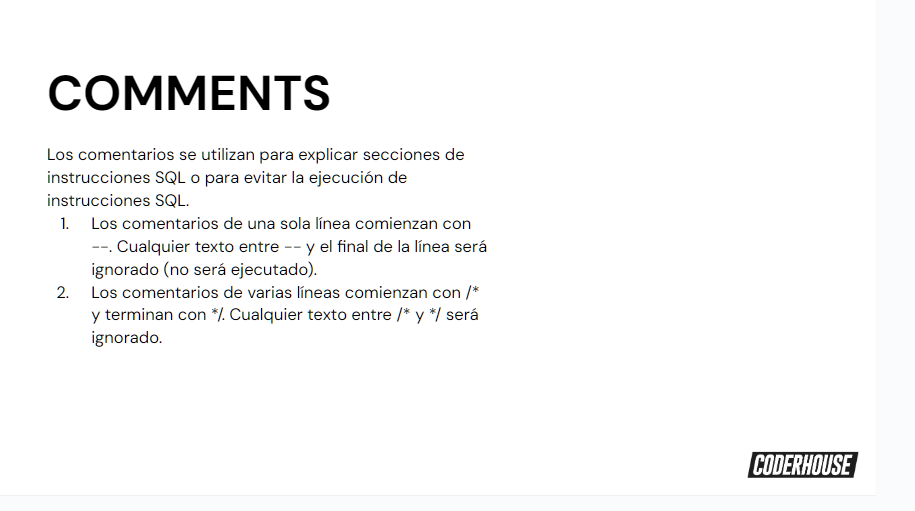

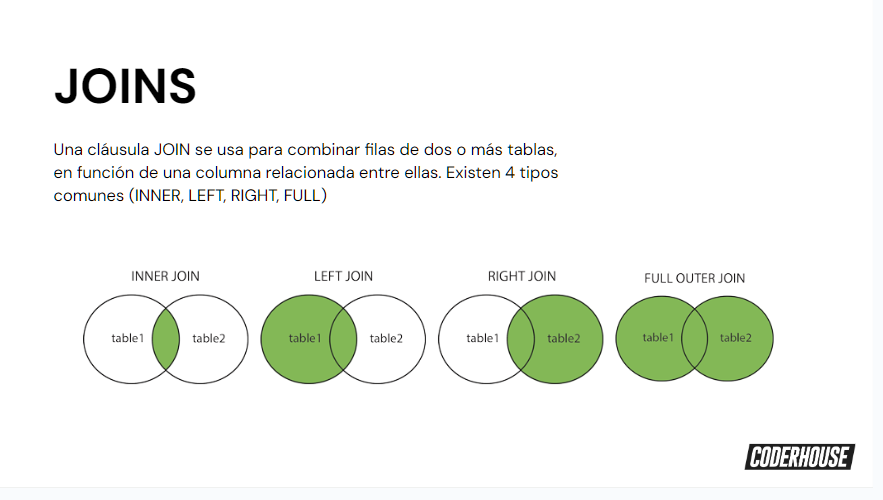

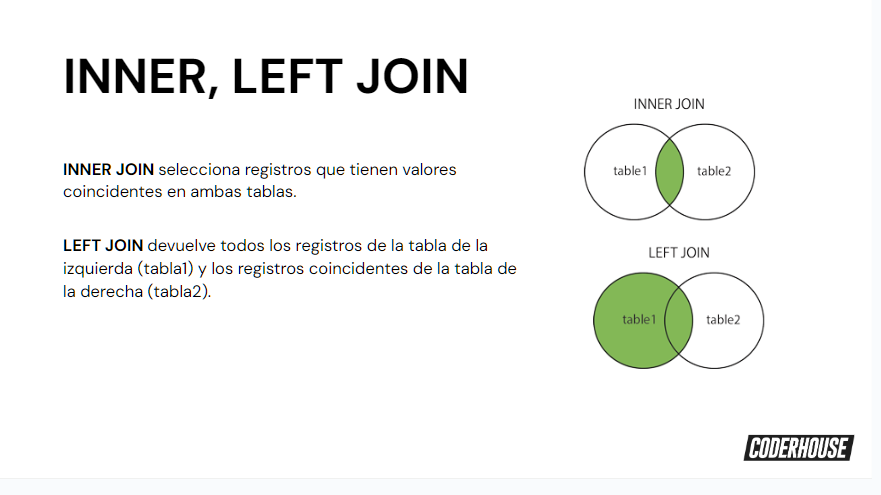

In [ ]:
# === INNER JOIN ===

import sqlite3
import pandas as pd

conn = sqlite3.connect("nba.sqlite")

query = """
SELECT
    Seasons_Stats.Player,
    Seasons_Stats.Tm,
    Seasons_Stats.PTS,
    NBA_season1718_salary.season17_18
FROM Seasons_Stats
INNER JOIN NBA_season1718_salary
    ON Seasons_Stats.Player = NBA_season1718_salary.Player
ORDER BY NBA_season1718_salary.season17_18 DESC
LIMIT 20;
"""

df_inner = pd.read_sql(query, conn)
conn.close()

display(df_inner)

,Player,Tm,PTS,season17_18
0,Stephen Curry,GSW,1399.0,34682550.0
1,Stephen Curry,GSW,1373.0,34682550.0
2,Stephen Curry,GSW,383.0,34682550.0
3,Stephen Curry,GSW,1786.0,34682550.0
4,Stephen Curry,GSW,1873.0,34682550.0
5,Stephen Curry,GSW,1900.0,34682550.0
6,Stephen Curry,GSW,2375.0,34682550.0
7,Stephen Curry,GSW,1999.0,34682550.0
8,LeBron James,CLE,1654.0,33285709.0
9,LeBron James,CLE,2175.0,33285709.0


In [ ]:
# === LEFT JOIN  ===

import sqlite3
import pandas as pd

conn = sqlite3.connect("nba.sqlite")

query = """
SELECT
    Seasons_Stats.Player,
    Seasons_Stats.Tm,
    Seasons_Stats.PTS,
    NBA_season1718_salary.season17_18
FROM Seasons_Stats
LEFT JOIN NBA_season1718_salary
    ON Seasons_Stats.Player = NBA_season1718_salary.Player
ORDER BY Seasons_Stats.PTS DESC
LIMIT 20;
"""

df_left = pd.read_sql(query, conn)
conn.close()

display(df_left)

,Player,Tm,PTS,season17_18
0,Wilt Chamberlain*,PHW,4029.0,NaN
1,Wilt Chamberlain*,SFW,3586.0,NaN
2,Michael Jordan*,CHI,3041.0,NaN
3,Wilt Chamberlain*,PHW,3033.0,NaN
4,Wilt Chamberlain*,SFW,2948.0,NaN
5,Michael Jordan*,CHI,2868.0,NaN
6,Kobe Bryant,LAL,2832.0,NaN
7,Bob McAdoo*,BUF,2831.0,NaN
8,Kareem Abdul-Jabbar*,MIL,2822.0,NaN
9,Rick Barry*,SFW,2775.0,NaN


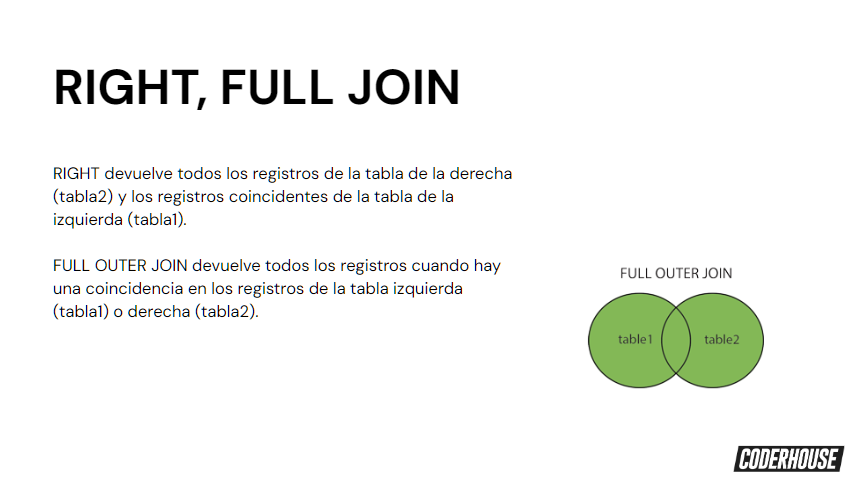

| JOIN  | Devuelve           |
| ----- | ------------------ |
| INNER | solo coincidencias |
| LEFT  | todo izquierda     |
| RIGHT | todo derecha       |
| FULL  | todo ambas         |


🏀 Uso real en Data Science

INNER → dataset final limpio para ML

LEFT → control de datos faltantes

RIGHT → análisis desde salarios

FULL → auditoría completa de calidad de datos

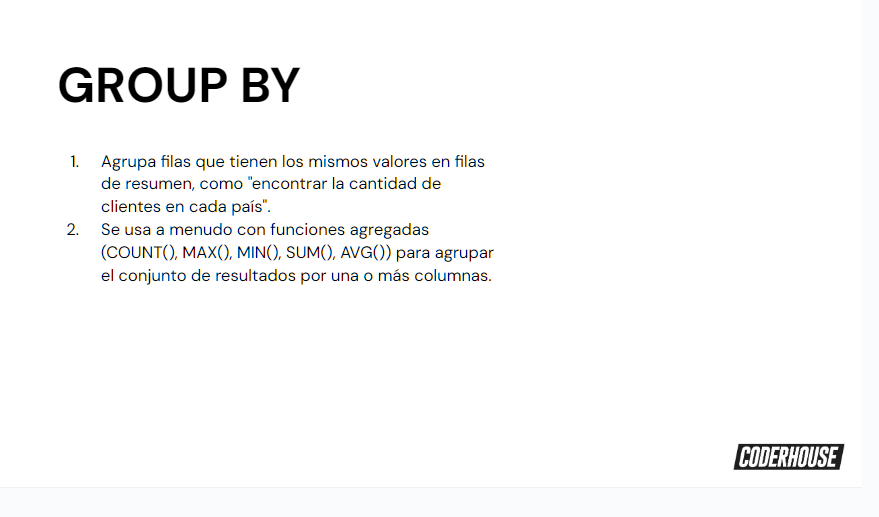

🧠 ¿Qué hace GROUP BY?

👉 Agrupa filas que tienen el mismo valor
y permite aplicar funciones agregadas:

COUNT() → contar

SUM() → sumar

AVG() → promedio

MAX() → máximo

MIN() → mínimo

In [ ]:
# === GROUP BY + COUNT ===

import sqlite3
import pandas as pd

conn = sqlite3.connect("nba.sqlite")

query = """
SELECT
    Tm AS equipo,
    COUNT(Player) AS cantidad_jugadores
FROM Seasons_Stats
GROUP BY Tm
ORDER BY cantidad_jugadores DESC;
"""

df_count = pd.read_sql(query, conn)
conn.close()

display(df_count)

,equipo,cantidad_jugadores
0,TOT,2123
1,NYK,1043
2,BOS,998
3,DET,917
4,PHI,871
...,...,...
65,STB,14
66,CAP,14
67,CHS,13
68,CHP,12


In [ ]:
# === GROUP BY + AVG ===

import sqlite3
import pandas as pd

conn = sqlite3.connect("nba.sqlite")

query = """
SELECT
    Tm AS equipo,
    AVG(PTS) AS promedio_puntos
FROM Seasons_Stats
GROUP BY Tm
ORDER BY promedio_puntos DESC;
"""

df_avg = pd.read_sql(query, conn)
conn.close()

display(df_avg)

,equipo,promedio_puntos
0,SDR,738.921569
1,CIN,685.792929
2,SFW,684.625000
3,BAL,642.819444
4,KCK,623.131944
...,...,...
65,BLB,268.410526
66,TRI,259.975610
67,WSC,252.814815
68,WAT,234.333333


In [ ]:
# === GROUP BY + SUM ===

import sqlite3
import pandas as pd

conn = sqlite3.connect("nba.sqlite")

query = """
SELECT
    Tm AS equipo,
    SUM(PTS) AS puntos_totales
FROM Seasons_Stats
GROUP BY Tm
ORDER BY puntos_totales DESC;
"""

df_sum = pd.read_sql(query, conn)
conn.close()

display(df_sum)

,equipo,puntos_totales
0,TOT,880467.0
1,BOS,568808.0
2,NYK,551292.0
3,DET,502184.0
4,LAL,499158.0
...,...,...
65,SHE,5108.0
66,STB,5010.0
67,WAT,4921.0
68,DNN,4817.0


In [ ]:
# === GROUP BY + MAX / MIN ===

import sqlite3
import pandas as pd

conn = sqlite3.connect("nba.sqlite")

query = """
SELECT
    Tm AS equipo,
    MAX(PTS) AS max_puntos,
    MIN(PTS) AS min_puntos
FROM Seasons_Stats
GROUP BY Tm;
"""

df_max_min = pd.read_sql(query, conn)
conn.close()

display(df_max_min)

,equipo,max_puntos,min_puntos
0,None,NaN,NaN
1,AND,1138.0,2.0
2,ATL,2397.0,0.0
3,BAL,2159.0,0.0
4,BLB,1269.0,0.0
...,...,...,...
65,VAN,1829.0,5.0
66,WAS,2346.0,0.0
67,WAT,892.0,14.0
68,WSB,1942.0,0.0


🧠 Orden lógico de SQL

FROM

→ WHERE

→ GROUP BY

→ HAVING

→ SELECT

→ ORDER BY

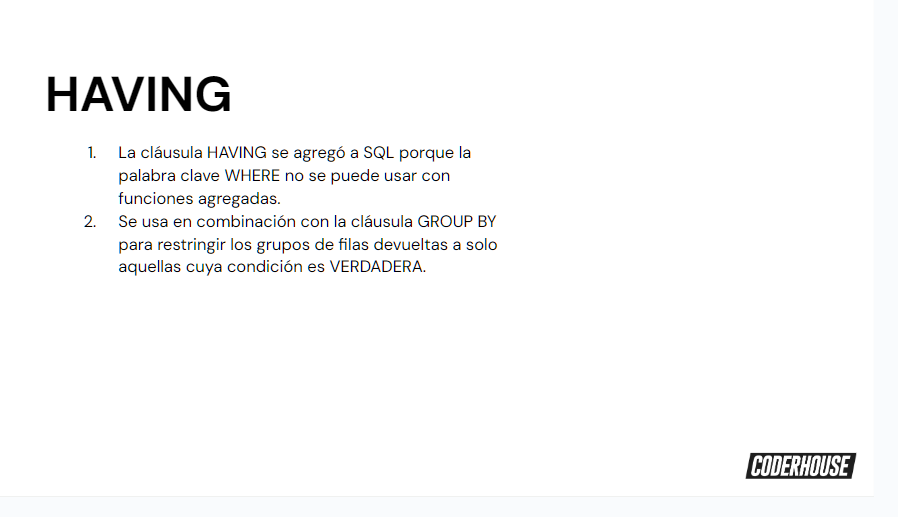

In [ ]:
# === GROUP BY sin HAVING ===


import sqlite3
import pandas as pd


conn = sqlite3.connect("nba.sqlite")


query = """
SELECT
Tm AS equipo,
COUNT(Player) AS cantidad_jugadores
FROM Seasons_Stats
GROUP BY Tm
ORDER BY cantidad_jugadores DESC;
"""


df_group = pd.read_sql(query, conn)
conn.close()


display(df_group)

,equipo,cantidad_jugadores
0,TOT,2123
1,NYK,1043
2,BOS,998
3,DET,917
4,PHI,871
...,...,...
65,STB,14
66,CAP,14
67,CHS,13
68,CHP,12


In [ ]:
# === GROUP BY + HAVING ===

import sqlite3
import pandas as pd

conn = sqlite3.connect("nba.sqlite")

query = """
SELECT
    Tm AS equipo,
    COUNT(Player) AS cantidad_jugadores
FROM Seasons_Stats
GROUP BY Tm
HAVING COUNT(Player) > 50
ORDER BY cantidad_jugadores DESC;
"""

df_having = pd.read_sql(query, conn)
conn.close()

display(df_having)

,equipo,cantidad_jugadores
0,TOT,2123
1,NYK,1043
2,BOS,998
3,DET,917
4,PHI,871
5,LAL,834
6,CHI,795
7,MIL,794
8,ATL,788
9,CLE,783


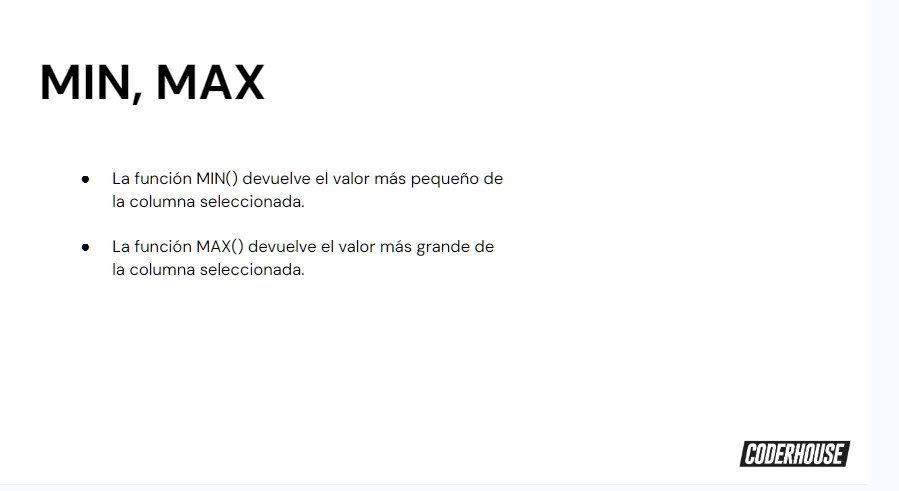

In [ ]:
# MIN y MAX ===

import sqlite3
import pandas as pd

conn = sqlite3.connect("nba.sqlite")

query = """
SELECT
    MIN(season17_18) AS salario_minimo,
    MAX(season17_18) AS salario_maximo
FROM NBA_season1718_salary;
"""

df_min_max = pd.read_sql(query, conn)
conn.close()

display(df_min_max)

,salario_minimo,salario_maximo
0,17224.0,34682550.0


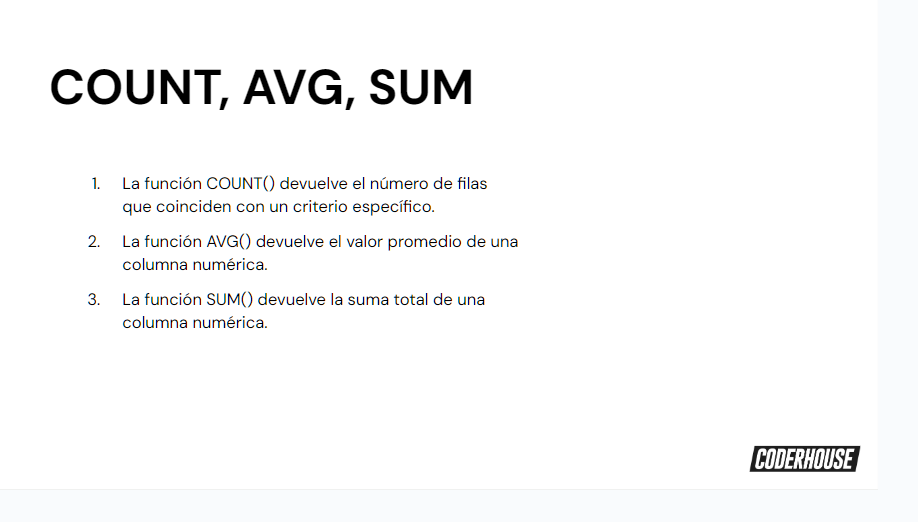

In [ ]:
# === COUNT ===

import sqlite3
import pandas as pd

conn = sqlite3.connect("nba.sqlite")

query = """
SELECT
    Tm AS equipo,
    COUNT(Player) AS cantidad_jugadores
FROM Seasons_Stats
GROUP BY Tm
ORDER BY cantidad_jugadores DESC;
"""

df_count = pd.read_sql(query, conn)
conn.close()

display(df_count)

,equipo,cantidad_jugadores
0,TOT,2123
1,NYK,1043
2,BOS,998
3,DET,917
4,PHI,871
...,...,...
65,STB,14
66,CAP,14
67,CHS,13
68,CHP,12


In [ ]:
# === AVG ===

import sqlite3
import pandas as pd

conn = sqlite3.connect("nba.sqlite")

query = """
SELECT
    Tm AS equipo,
    AVG(PTS) AS promedio_puntos
FROM Seasons_Stats
GROUP BY Tm
ORDER BY promedio_puntos DESC;
"""

df_avg = pd.read_sql(query, conn)
conn.close()

display(df_avg)

,equipo,promedio_puntos
0,SDR,738.921569
1,CIN,685.792929
2,SFW,684.625000
3,BAL,642.819444
4,KCK,623.131944
...,...,...
65,BLB,268.410526
66,TRI,259.975610
67,WSC,252.814815
68,WAT,234.333333


In [ ]:
# === SUM ===

import sqlite3
import pandas as pd

conn = sqlite3.connect("nba.sqlite")

query = """
SELECT
    Tm AS equipo,
    SUM(PTS) AS total_puntos
FROM Seasons_Stats
GROUP BY Tm
ORDER BY total_puntos DESC;
"""

df_sum = pd.read_sql(query, conn)
conn.close()

display(df_sum)

,equipo,total_puntos
0,TOT,880467.0
1,BOS,568808.0
2,NYK,551292.0
3,DET,502184.0
4,LAL,499158.0
...,...,...
65,SHE,5108.0
66,STB,5010.0
67,WAT,4921.0
68,DNN,4817.0


In [ ]:
# === COUNT con WHERE ===

import sqlite3
import pandas as pd

conn = sqlite3.connect("nba.sqlite")

query = """
SELECT
    COUNT(*) AS jugadores_1000_puntos
FROM Seasons_Stats
WHERE PTS > 1000;
"""

df_count_where = pd.read_sql(query, conn)
conn.close()

display(df_count_where)

,jugadores_1000_puntos
0,4036


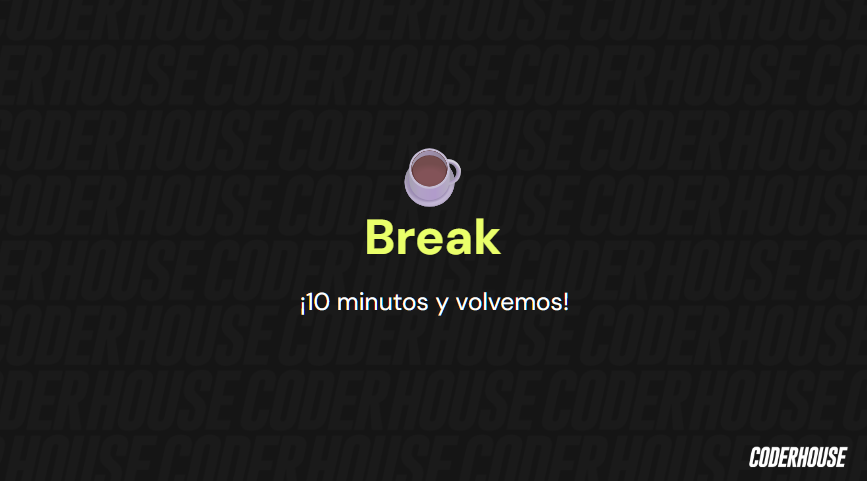

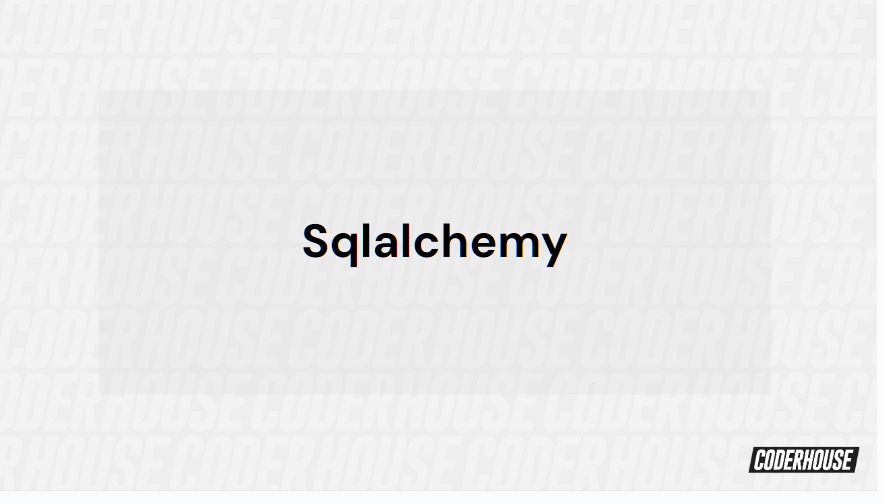

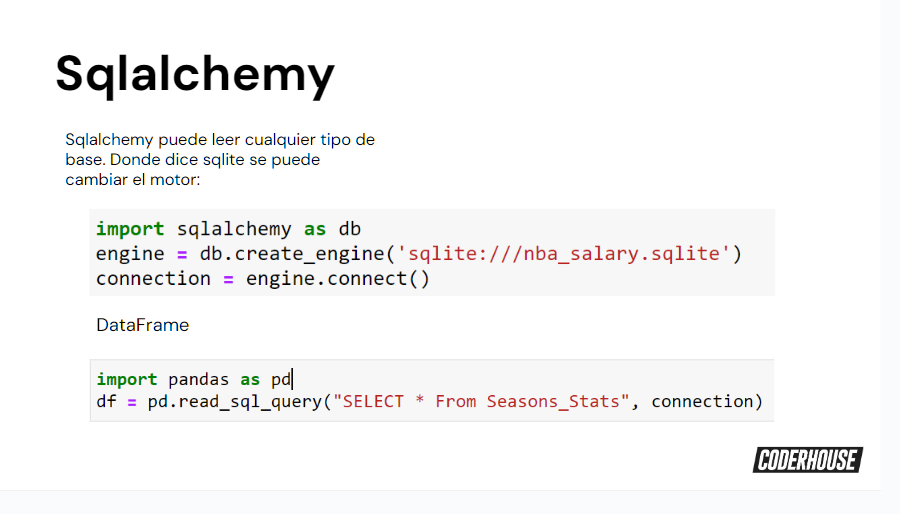

In [ ]:
!pip install sqlalchemy

In [ ]:
from sqlalchemy import create_engine, text
import pandas as pd

In [ ]:
engine = create_engine("sqlite:///nba.sqlite")

In [ ]:
query = """
SELECT Player, Tm, PTS
FROM Seasons_Stats
WHERE PTS > 2000
ORDER BY PTS DESC
LIMIT 10;
"""


df = pd.read_sql(query, engine)
display(df)

,Player,Tm,PTS
0,Wilt Chamberlain*,PHW,4029.0
1,Wilt Chamberlain*,SFW,3586.0
2,Michael Jordan*,CHI,3041.0
3,Wilt Chamberlain*,PHW,3033.0
4,Wilt Chamberlain*,SFW,2948.0
5,Michael Jordan*,CHI,2868.0
6,Kobe Bryant,LAL,2832.0
7,Bob McAdoo*,BUF,2831.0
8,Kareem Abdul-Jabbar*,MIL,2822.0
9,Rick Barry*,SFW,2775.0


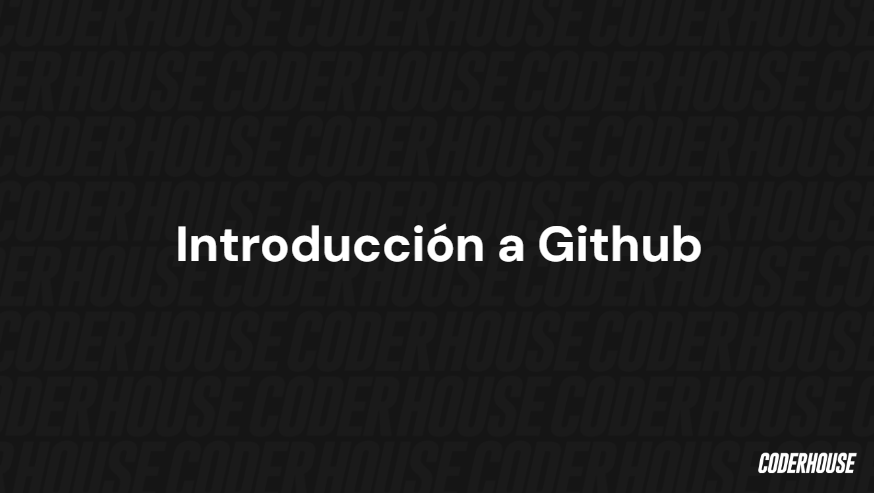

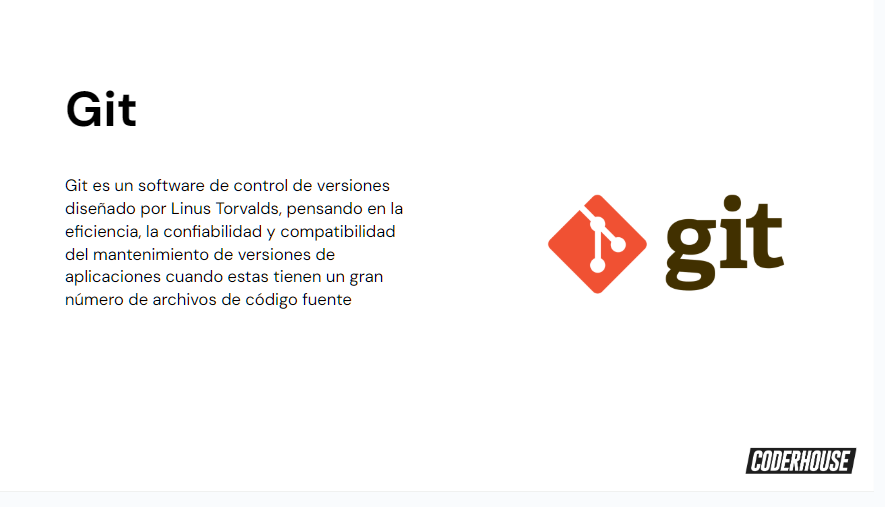

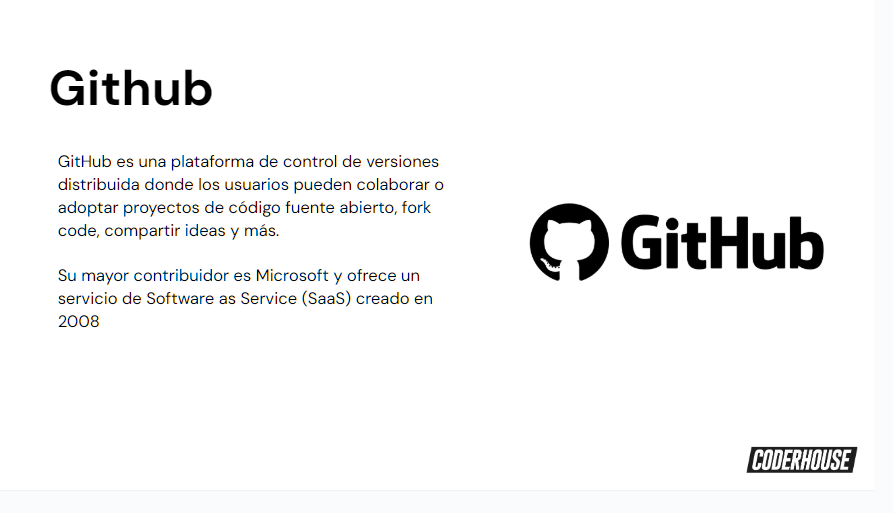

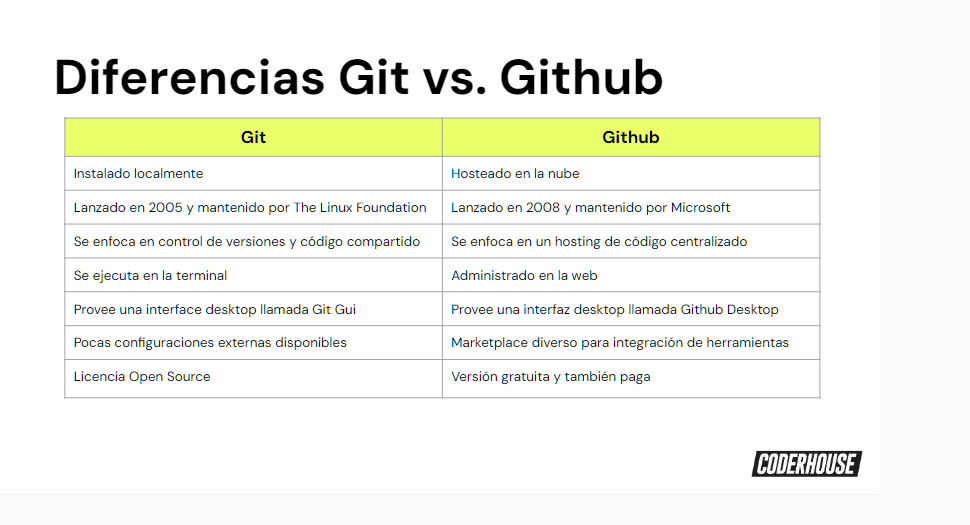

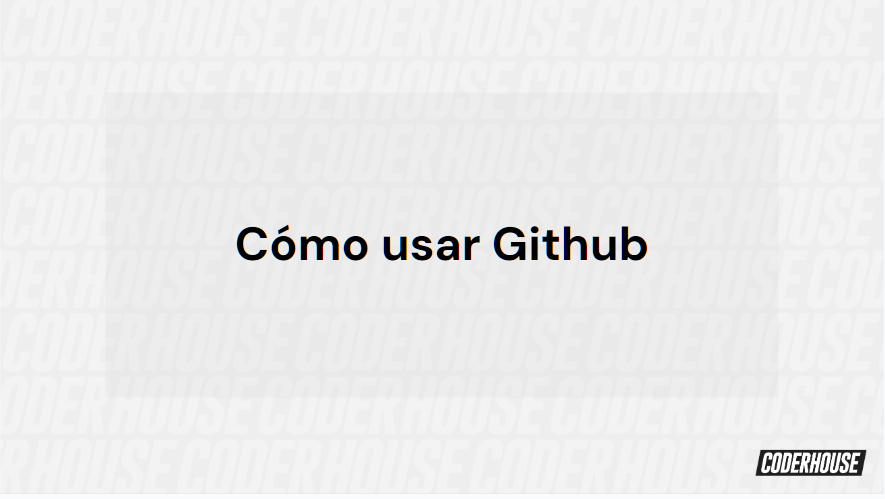

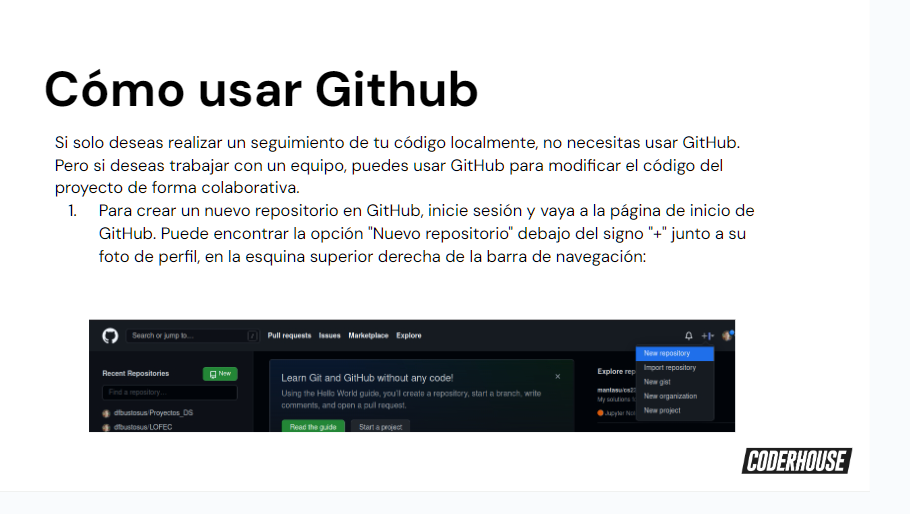

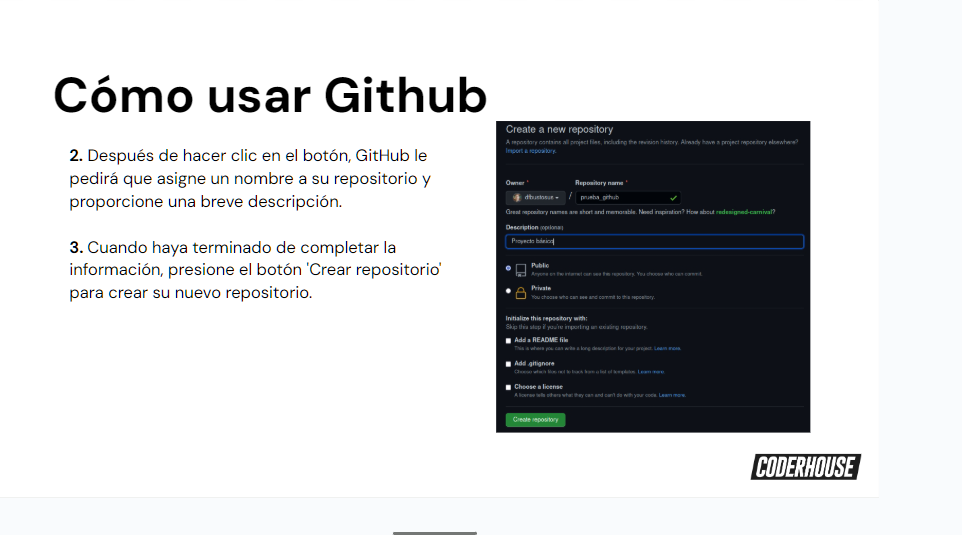

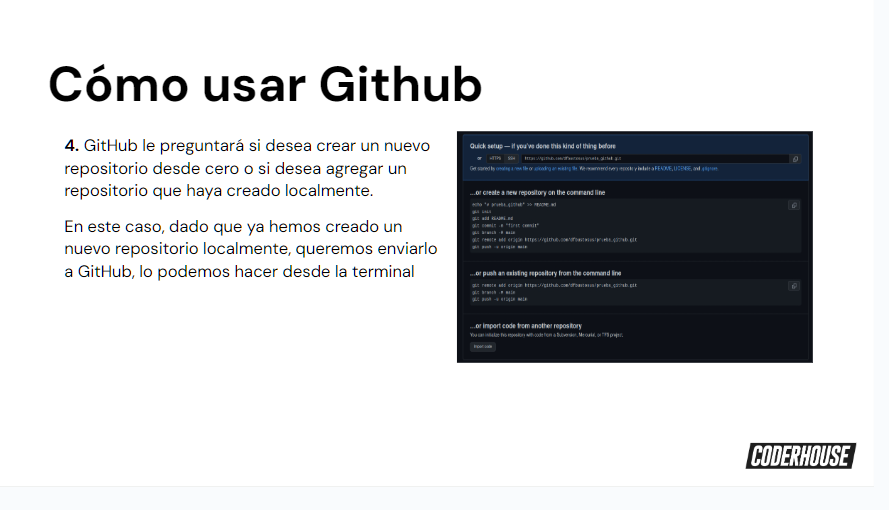

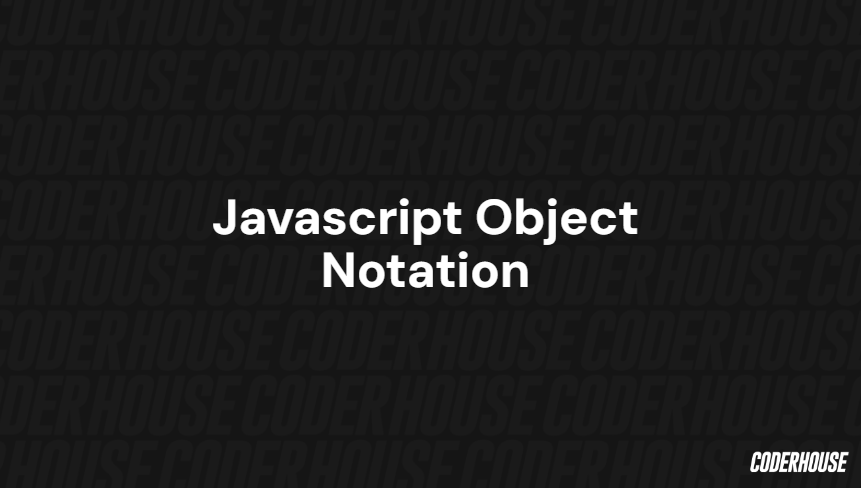

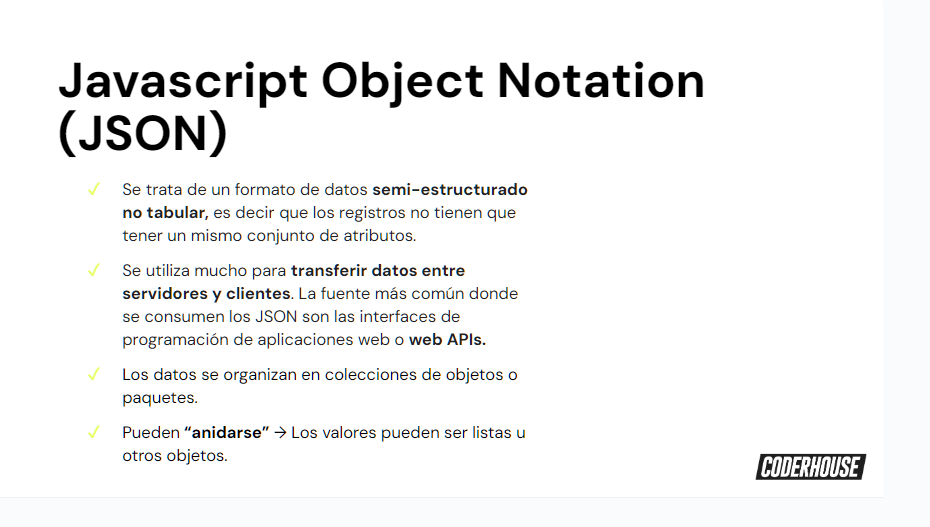

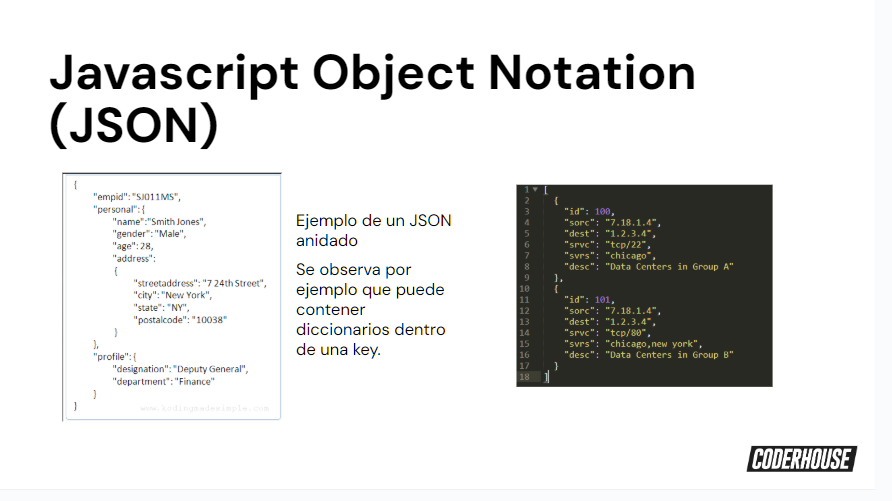

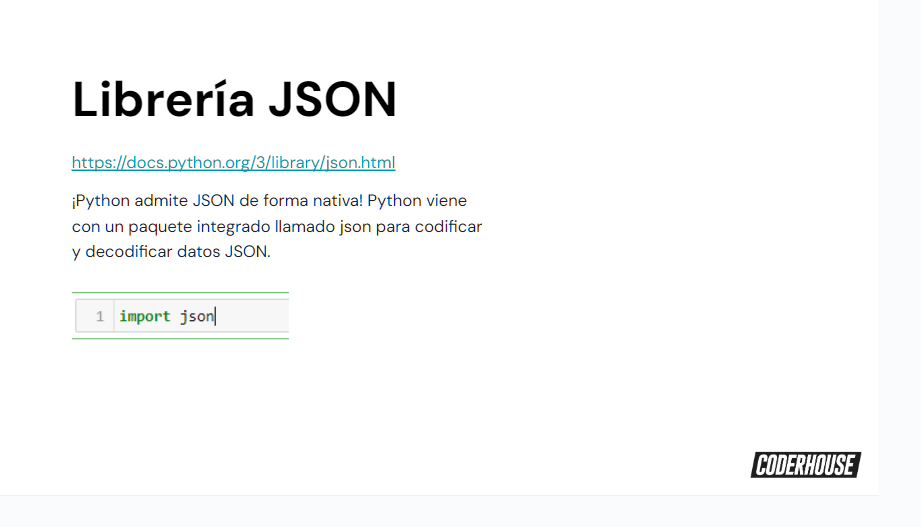

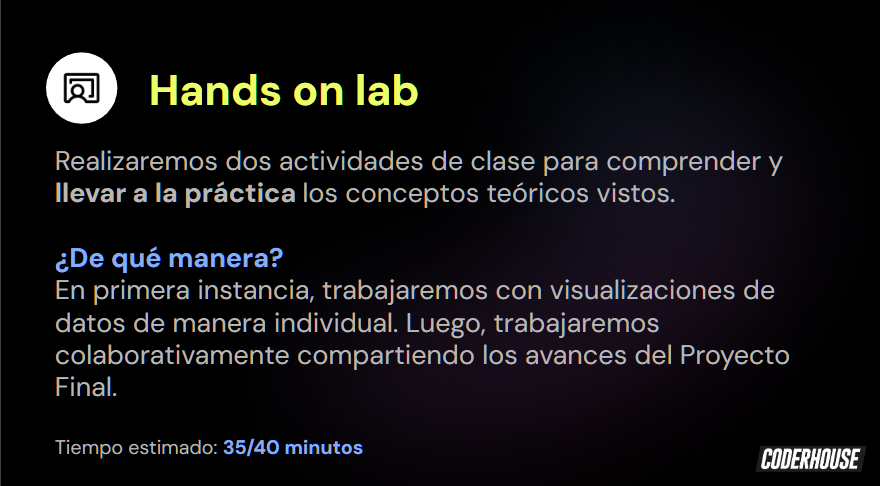

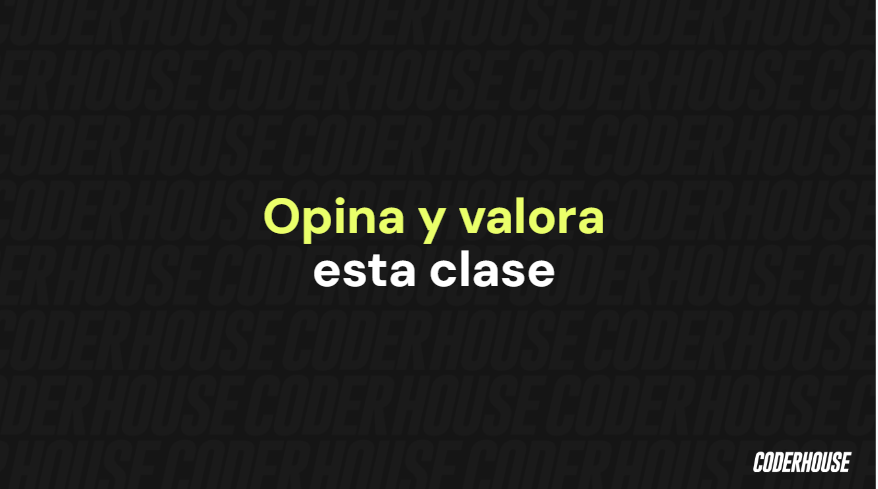

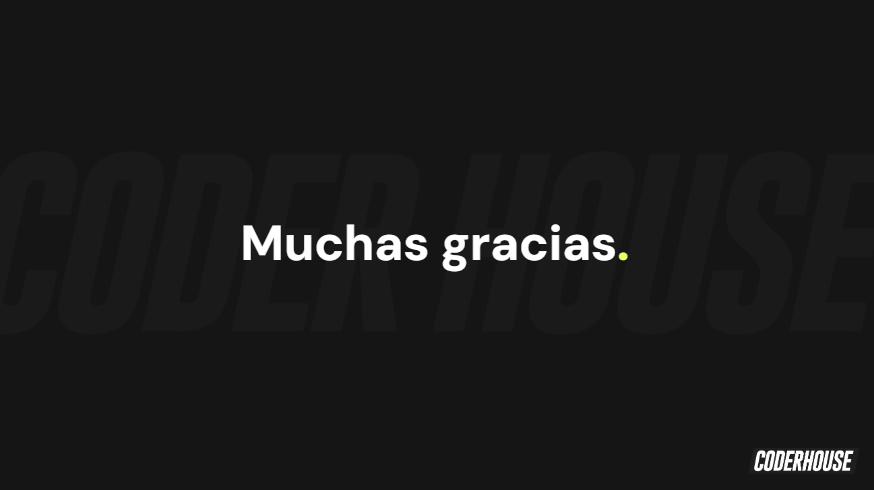

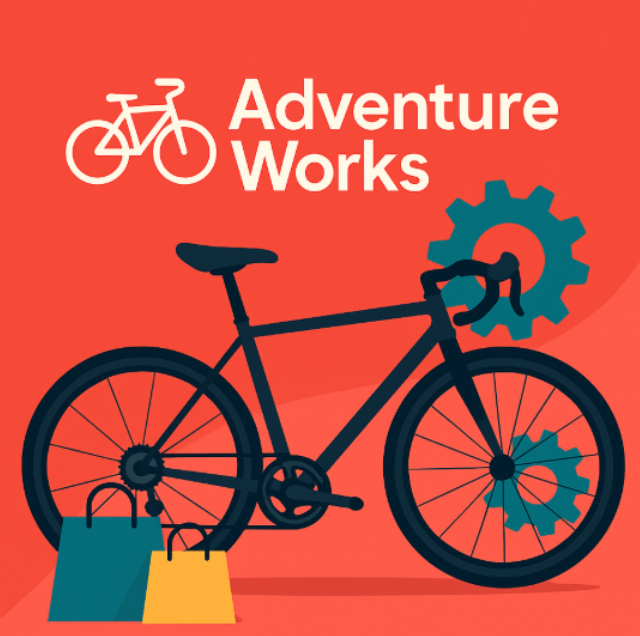

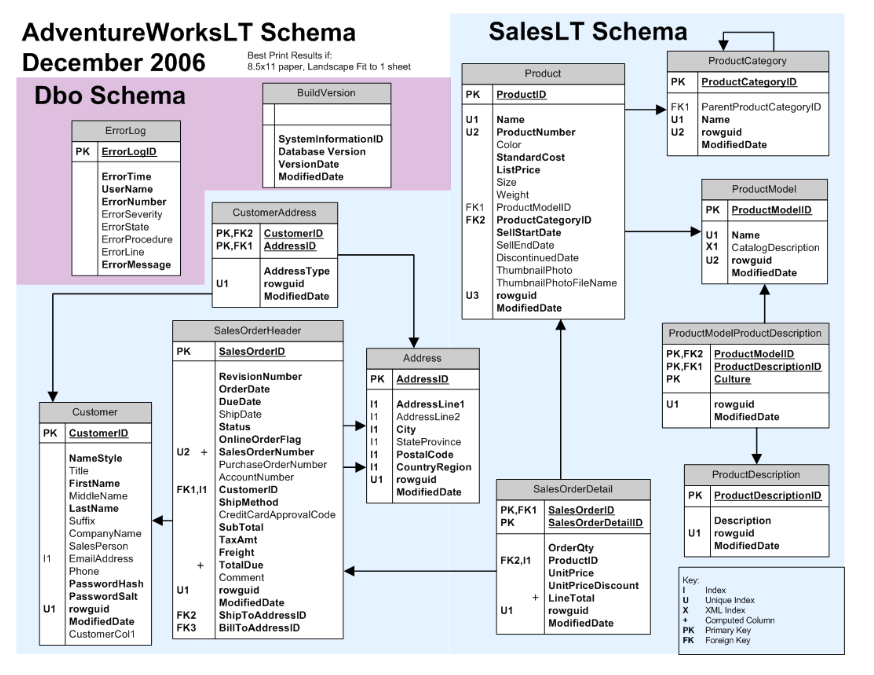

Listado de tablas:

BuildVersion

Address

Customer

CustomerAddress

ErrorLog

Product

ProductCategory

ProductModel

ProductDescription

ProductModel

ProductDescription

SalesOrderDetail

SalesOrderHeader

In [ ]:
!pip install -q gdown

import sqlite3
import pandas as pd
import subprocess
from pathlib import Path

# ID del archivo en Google Drive
file_id = "1kiuj0_4SBP2xnnVmbSjXIU0SkZEnRCWx"
db_file = "AdventureWorks.db"

# Descargar base desde Drive
subprocess.run(["gdown", "--id", file_id, "-O", db_file], check=True)

# Verificar descarga
if not Path(db_file).exists():
    raise FileNotFoundError("No se pudo descargar la base de datos")

# Conexión SQLite
conn = sqlite3.connect(db_file)

# Listar tablas
tablas = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

print("Tablas disponibles:")
display(tablas)

df = pd.read_sql("SELECT * FROM SalesOrderHeader;", conn)

conn.close()

df
df.columns

Tablas disponibles:


,name
0,ErrorLog
1,sqlite_sequence
2,BuildVersion
3,Address
4,Customer
5,CustomerAddress
6,Product
7,ProductCategory
8,ProductDescription
9,ProductModel


Index(['SalesOrderID', 'RevisionNumber', 'OrderDate', 'DueDate', 'ShipDate',
       'Status', 'OnlineOrderFlag', 'SalesOrderNumber', 'PurchaseOrderNumber',
       'AccountNumber', 'CustomerID', 'ShipToAddressID', 'BillToAddressID',
       'ShipMethod', 'CreditCardApprovalCode', 'SubTotal', 'TaxAmt', 'Freight',
       'TotalDue', 'Comment', 'rowguid', 'ModifiedDate'],
      dtype='object')

##Ejercicio 1 — Principiante

Problema de Negocio (Markdown):

El gerente de ventas quiere ver las órdenes más relevantes para validar casos de facturación. Necesita un listado rápido de los últimos 20 pedidos con TotalDue mayor a 5.000, ordenados por fecha de pedido descendente, para revisar posibles anomalías.

Concepto Teórico (Markdown):

Filtrado con WHERE y ordenamiento con ORDER BY. LIMIT (SQLite) se usa para devolver una muestra manejable. Seleccionamos columnas relevantes para inspección.

##Ejercicio 2 — Intermedio

Problema de Negocio (Markdown):

El equipo de producto quiere saber qué categorías generan más ingresos. Necesitan el total de ventas por categoría de producto y la media de precio unitario para comparar rentabilidades por categoría.

Concepto Teórico (Markdown):

JOIN para traer SalesOrderDetail → Product → ProductCategory. Agregación con SUM() para ventas totales y AVG() para precio promedio. GROUP BY por categoría y ORDER BY para ranking.

In [ ]:
#  Descargar DB y abrir conexión (ejecutar una vez)
!pip install -q gdown

import sqlite3
import pandas as pd
import subprocess
from pathlib import Path

# ID del archivo en Google Drive (el que proporcionaste)
file_id = "1kiuj0_4SBP2xnnVmbSjXIU0SkZEnRCWx"
db_file = "AdventureWorks.db"

# Descargar
subprocess.run(["gdown", "--id", file_id, "-O", db_file], check=True)

if not Path(db_file).exists():
    raise FileNotFoundError("No se pudo descargar la base de datos")

# Conexión SQLite global para las celdas siguientes
conn = sqlite3.connect(db_file)

# Mostrar tablas (diagnóstico rápido)
tablas = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", conn)
print("Tablas disponibles:")
display(tablas)

Tablas disponibles:


,name
0,Address
1,BuildVersion
2,Customer
3,CustomerAddress
4,ErrorLog
5,Product
6,ProductCategory
7,ProductDescription
8,ProductModel
9,ProductModelProductDescription
